# Telco Customer Churn — Exploratory Data Analysis

Goal: understand which customer attributes correlate with churn before building a model. This drives feature engineering decisions in `src/train.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/telco_churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,C00000,Male,0,Yes,No,16,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,27.70,431.91,No
1,C00001,Female,0,No,No,25,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Electronic check,30.02,782.49,No
2,C00002,Female,1,No,Yes,62,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),18.00,1191.41,No
3,C00003,Male,0,No,Yes,7,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Electronic check,105.27,772.83,Yes
4,C00004,Male,0,No,No,7,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,No,One year,No,Electronic check,56.67,405.97,No


In [2]:
print(df.shape)
print(df["Churn"].value_counts(normalize=True))
df.isna().sum()[df.isna().sum() > 0]

(5000, 21)
Churn
No     0.6644
Yes    0.3356
Name: proportion, dtype: float64


Series([], dtype: int64)

## Class balance

Churn is imbalanced (~30/70). This is why `train.py` uses `class_weight="balanced"` for logistic regression and `scale_pos_weight` for XGBoost, and why we track ROC-AUC / F1 rather than raw accuracy.

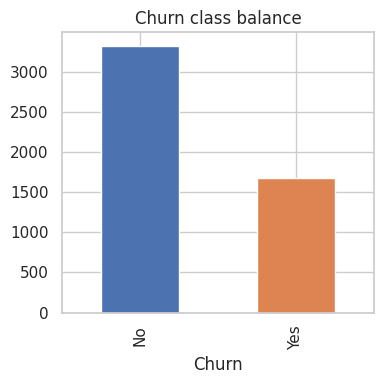

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))
df["Churn"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Churn class balance")
plt.tight_layout()
plt.savefig("churn_balance.png", dpi=100)
plt.show()

## Tenure vs churn

Customers who churn tend to have much shorter tenure — this is one of the strongest signals in the dataset and shows up as a top feature later.

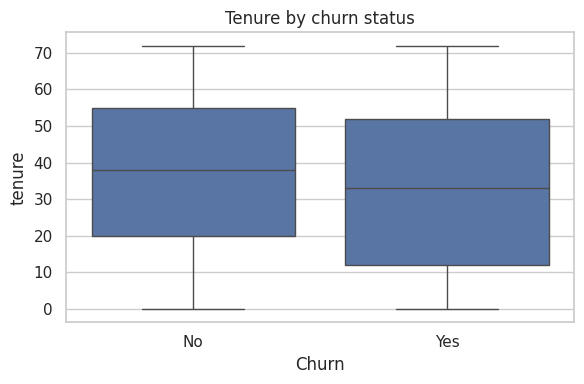

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="tenure", ax=ax)
ax.set_title("Tenure by churn status")
plt.tight_layout()
plt.savefig("tenure_vs_churn.png", dpi=100)
plt.show()

## Contract type vs churn

Month-to-month customers churn at a much higher rate than one- or two-year contract holders — the single strongest categorical predictor, later confirmed by XGBoost feature importances.

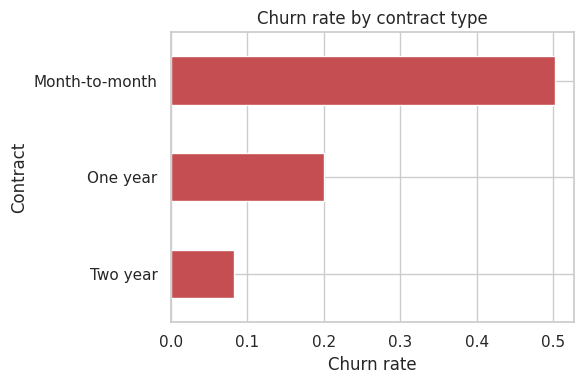

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_contract = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean())
churn_by_contract.sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("Churn rate")
ax.set_title("Churn rate by contract type")
plt.tight_layout()
plt.savefig("contract_vs_churn.png", dpi=100)
plt.show()

## Monthly charges vs churn

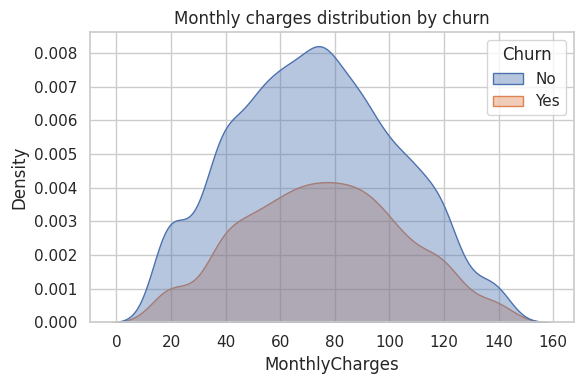

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, alpha=0.4, ax=ax)
ax.set_title("Monthly charges distribution by churn")
plt.tight_layout()
plt.savefig("charges_vs_churn.png", dpi=100)
plt.show()

## Takeaways for modeling

1. **Contract type, tenure, and internet service type** are the strongest predictors — this matches what tree-based feature importance shows in `src/train.py`.
2. **Class imbalance (~30% churn)** means accuracy alone is misleading; the pipeline optimizes and reports ROC-AUC and F1 instead.
3. **TotalCharges has missing values** for brand-new customers (0-month tenure) — handled via median imputation in the preprocessing pipeline.
4. Categorical features dominate (contract, tech support, payment method) — a `OneHotEncoder` + linear model is a strong, interpretable baseline before reaching for more complex models.